#Trabajo Práctico 2 - Críticas Cinematográficas

#Grupo 2 - G2 - Integrantes:

- Calderan, Facundo Andres
- Merlinsky Camins, Mariano Gabriel
- Castellano Bogdan, Benjamin
- Pons Echeverria, Tomas

# Bayes Naive

In [1]:
import pandas as pd
import joblib

# Descargamos los archivos
!gdown 14x5sadizIqZZSNi-ILTXevwIZjBgTonS
!gdown 1MV2mivzC_7gLCqRndSnWizXRGhJBgQ6L
!gdown 1GpCc2ggdH9X4nrfbO80ubK4GF5NGtrzk

# Descargamos un modelo linguistico para lemmatizar las palabras (Ejemplo: corrimos -> correr)
!pip install spacy
!python -m spacy download es_core_news_lg

Downloading...
From: https://drive.google.com/uc?id=14x5sadizIqZZSNi-ILTXevwIZjBgTonS
To: /content/sample_solution.csv
100% 299/299 [00:00<00:00, 979kB/s]
Downloading...
From: https://drive.google.com/uc?id=1MV2mivzC_7gLCqRndSnWizXRGhJBgQ6L
To: /content/test.csv
100% 11.1M/11.1M [00:00<00:00, 78.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GpCc2ggdH9X4nrfbO80ubK4GF5NGtrzk
To: /content/train.csv
100% 72.2M/72.2M [00:01<00:00, 37.1MB/s]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 1.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# Cargamos los archivos en dataframes
data_train = pd.read_csv('train.csv')
data_test = pd.read_csv('test.csv')

print(data_train.info())
data_train

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           50000 non-null  int64 
 1   review_es    50000 non-null  object
 2   sentimiento  50000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB
None


,ID,review_es,sentimiento
0,0,Uno de los otros críticos ha mencionado que de...,positivo
1,1,Una pequeña pequeña producción.La técnica de f...,positivo
2,2,Pensé que esta era una manera maravillosa de p...,positivo
3,3,"Básicamente, hay una familia donde un niño peq...",negativo
4,4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
...,...,...,...
49995,49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,49998,Voy a tener que estar en desacuerdo con el com...,negativo


## Preprocesamiento

In [3]:
import re
import nltk
import spacy
from nltk.corpus import stopwords
from sklearn.base import BaseEstimator, TransformerMixin


nltk.download('stopwords')
stop_words = set(stopwords.words('spanish')) - {
    "no", "sí", "nada", "nunca", "siempre",
    "muy", "mucho", "poco", "bastante",
    "pero", "aunque", "sin embargo"
}
nlp = spacy.load("es_core_news_lg", disable=["parser", "ner"])

def limpiar_texto(X):
    # Eliminar signos de puntuacion y minusculas
    textos = [re.sub(r"[^a-záéíóúüñ ]", "", t.lower()) for t in X]

    # Eliminamos stopwords
    textos = [" ".join([p for p in t.split() if p not in stop_words]) for t in textos]

    # Lematización
    docs = nlp.pipe(textos, batch_size=500, n_process=-1)
    return [" ".join([token.lemma_ for token in doc]) for doc in docs]


data_train['review_es'] = limpiar_texto(data_train['review_es'])
data_test['review_es'] = limpiar_texto(data_test['review_es'])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
def testear_clasificacion(y_train, y_test, y_train_pred, y_test_pred):
  # Métricas
  metrics = {
      "accuracy": [
          accuracy_score(y_train, y_train_pred),
          accuracy_score(y_test, y_test_pred)
      ],
      "precision": [
          precision_score(y_train, y_train_pred, pos_label='positivo'),
          precision_score(y_test, y_test_pred, pos_label='positivo')
      ],
      "recall": [
          recall_score(y_train, y_train_pred, pos_label='positivo'),
          recall_score(y_test, y_test_pred, pos_label='positivo')
      ],
      "f1_score": [
          f1_score(y_train, y_train_pred, pos_label='positivo'),
          f1_score(y_test, y_test_pred, pos_label='positivo')
      ]
  }

  # Crear tabla
  results = pd.DataFrame(metrics, index=["Train", "Test"])

  # Graficar tabla
  fig, ax = plt.subplots(figsize=(6, 2))
  ax.axis('off')
  ax.axis('tight')
  ax.table(cellText=results.round(3).values,
          colLabels=results.columns,
          rowLabels=results.index,
          loc='center')
  plt.title("Comparativa de métricas: Train vs Test", pad=10)
  plt.show()


  # Graficar Matriz de confusión
  cm = confusion_matrix(y_test, y_test_pred)
  ConfusionMatrixDisplay(cm).plot(cmap='Blues')
  plt.title("Matriz de confusión")
  plt.show()

In [5]:
x = data_train['review_es']
y = data_train['sentimiento']
x_test = data_test['review_es']

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(x, y,
                                                            test_size = 0.2,
                                                            random_state = 42,
                                                            stratify = y
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


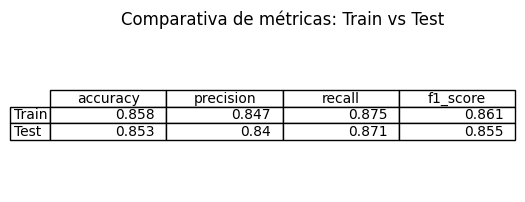

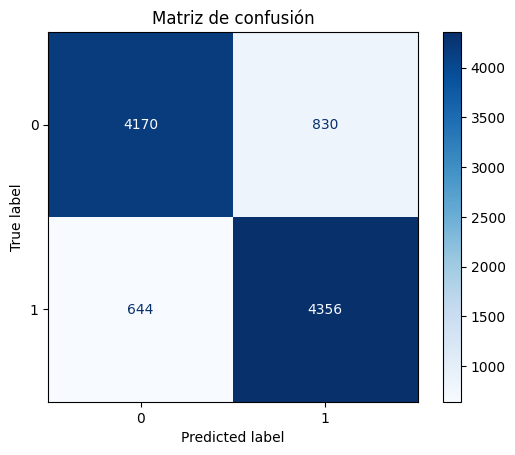

In [6]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# Utilizamos TF-IDF en vez de BoW
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        min_df=2,               # Ignorar términos muy raros
        max_df=0.95             # Ignorar términos muy frecuentes
    )),
    ('classifier', MultinomialNB())
])

param_grid = {
    'vectorizer__max_features': [8000, 9000],
    'vectorizer__ngram_range': [(1,1), (1, 2), (1,3)],
    'vectorizer__sublinear_tf': [True],
    'classifier__alpha': [0.1, 0.25, 0.5, 0.75, 1.0],
    'classifier__fit_prior': [True]
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring="f1_macro", verbose=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_nb = grid_search.best_estimator_

y_train_pred = best_nb.predict(X_train)
y_val_pred = best_nb.predict(X_val)
testear_clasificacion(y_train, y_val, y_train_pred, y_val_pred)


data_test['sentimiento'] = best_nb.predict(x_test)

In [7]:
data_test = data_test.drop('review_es', axis=True)

In [8]:
data_test.to_csv('submission.csv', index=False)

In [9]:
grid_search.best_params_

{'classifier__alpha': 0.25,
 'classifier__fit_prior': True,
 'vectorizer__max_features': 9000,
 'vectorizer__ngram_range': (1, 3),
 'vectorizer__sublinear_tf': True}

In [10]:
import joblib

joblib.dump(best_nb, 'naive_bayes_model.joblib')

['naive_bayes_model.joblib']